In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('fivethirtyeight')
sns.set_palette("viridis")


df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

print(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB
None


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


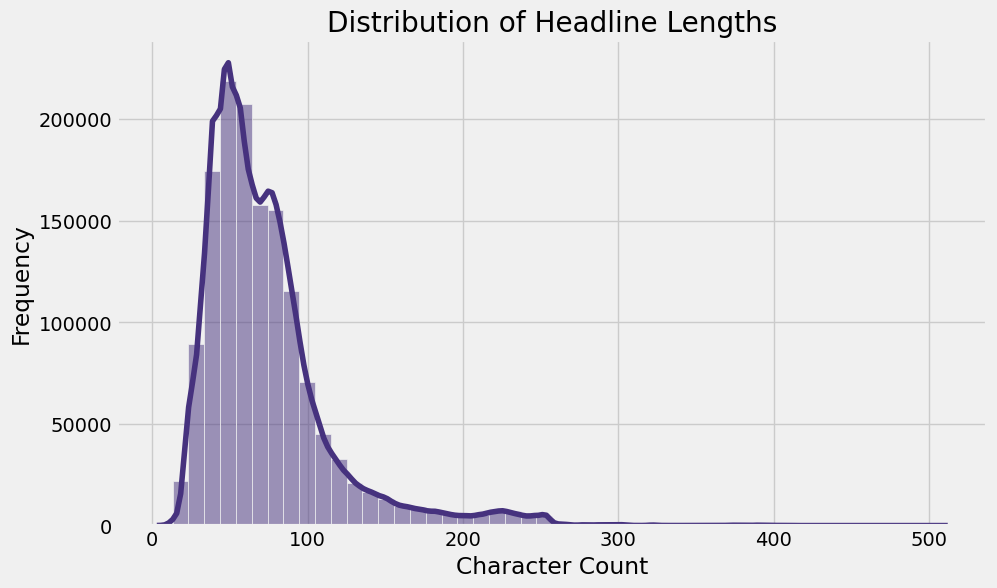

Average Headline Length: 73.12 characters


In [2]:
# Calculate headline lengths
df['headline_len'] = df['headline'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(df['headline_len'], bins=50, kde=True)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.show()

print(f"Average Headline Length: {df['headline_len'].mean():.2f} characters")

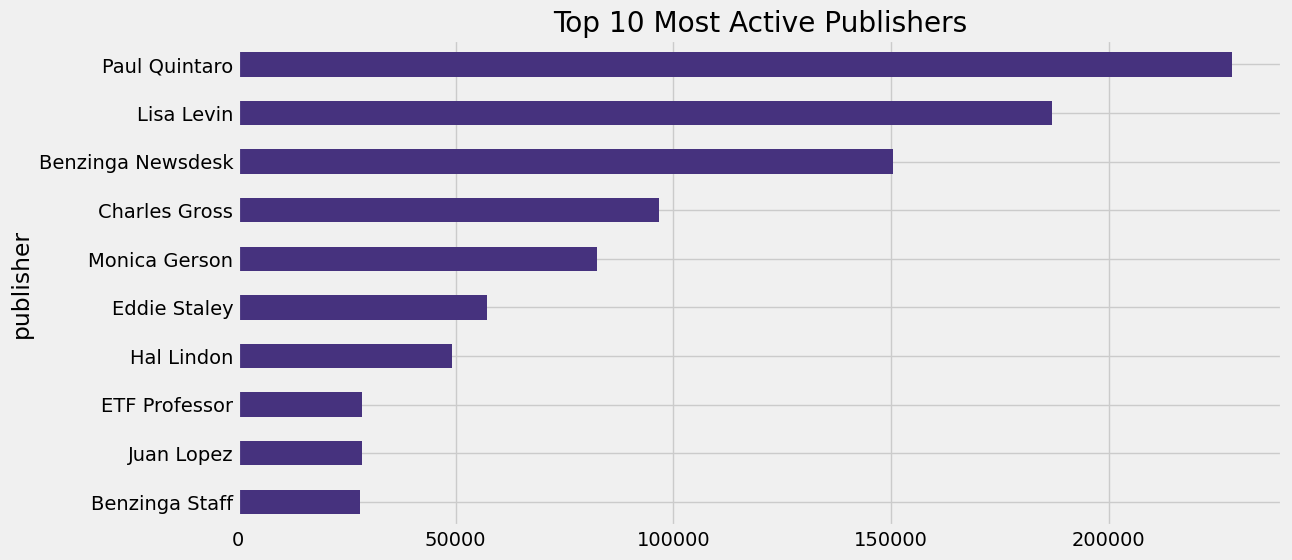

In [3]:
# Check top publishers
publisher_counts = df['publisher'].value_counts().head(10)

# Visualization
plt.figure(figsize=(12, 6))
publisher_counts.plot(kind='barh')
plt.title('Top 10 Most Active Publishers')
plt.gca().invert_yaxis() # Highest on top
plt.show()

Paul Quintaro and Lisa Levin are the top contributors.

Missing dates: 1351341


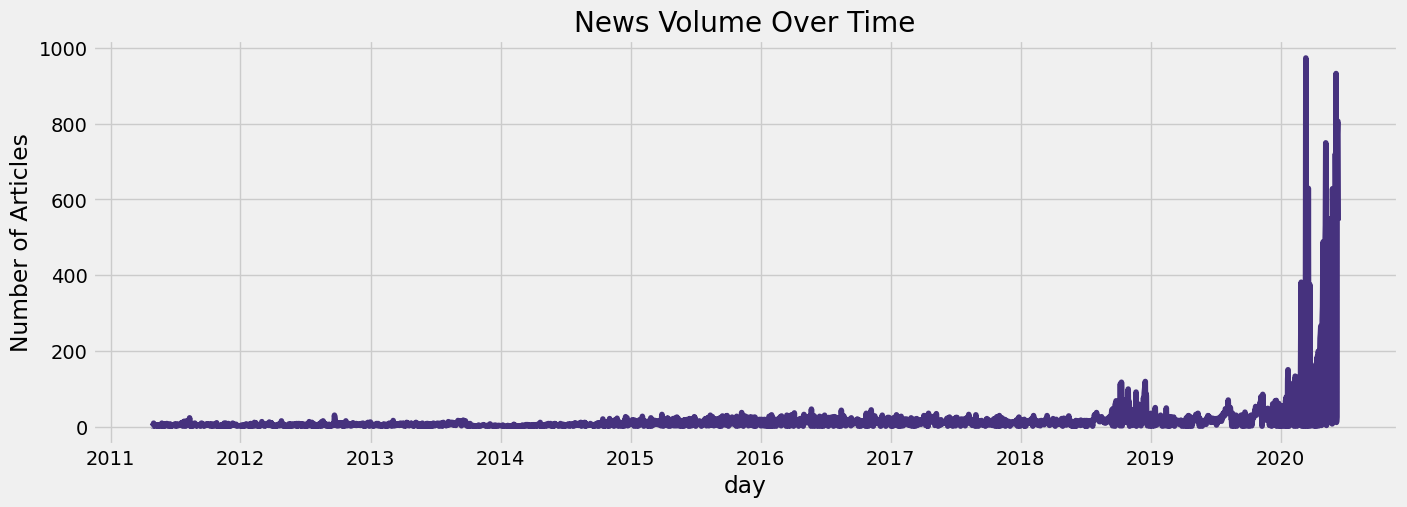

In [4]:
# Convert to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Check for null dates after conversion
print(f"Missing dates: {df['date'].isnull().sum()}")

# News volume over time
df['day'] = df['date'].dt.date
daily_news = df.groupby('day').size()

plt.figure(figsize=(15, 5))
daily_news.plot()
plt.title('News Volume Over Time')
plt.ylabel('Number of Articles')
plt.grid(True)
plt.show()

A massive jump in news starts in 2020, providing us with plenty of data during the pandemic era.

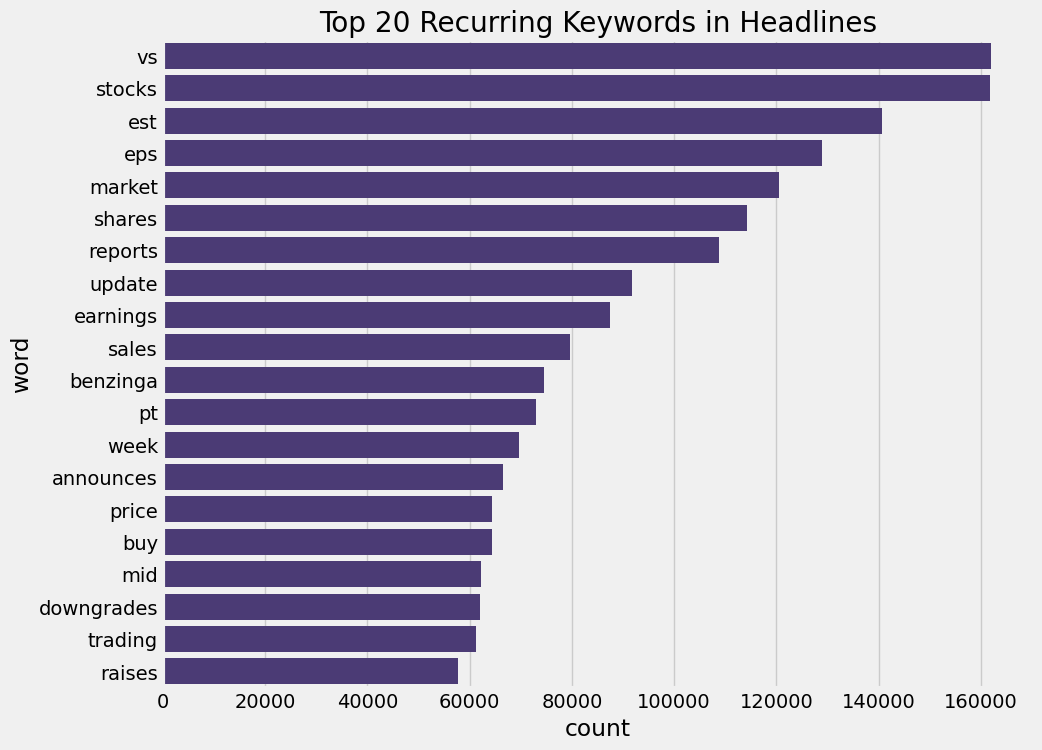

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Simple keyword extraction (Top 20 words)
# 'stop_words' removes common filler words like 'the', 'is', 'at'
cv = CountVectorizer(stop_words='english', max_features=20)
words = cv.fit_transform(df['headline'])
sum_words = words.sum(axis=0)

words_freq = [(word, sum_words[0, idx]) for word, idx in cv.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# Create a DF for plotting
word_df = pd.DataFrame(words_freq, columns=['word', 'count'])

plt.figure(figsize=(10, 8))
sns.barplot(x='count', y='word', data=word_df)
plt.title('Top 20 Recurring Keywords in Headlines')
plt.show()

words like "Earnings" and "EPS" dominate, confirming the data is focused on company performance.

C:\Users\abbadal\AppData\Local\Temp\ipykernel_23724\4237986881.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette="magma")


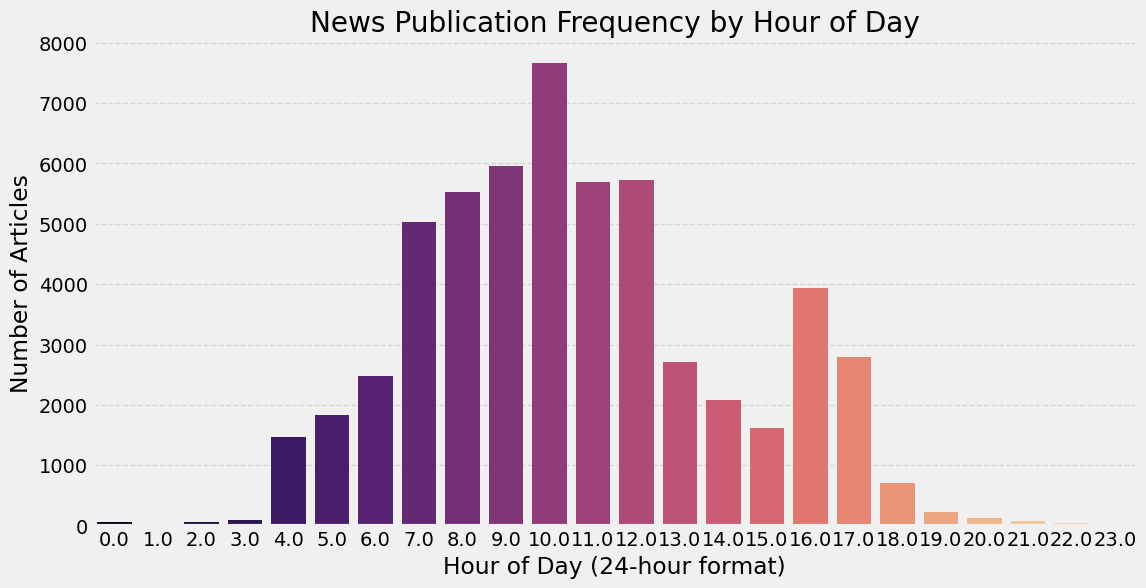

The busiest hour for news is 10.0:00.


In [7]:
# 1. Extract the hour from the date column
df['hour'] = df['date'].dt.hour

# 2. Count news per hour
hourly_counts = df['hour'].value_counts().sort_index()

# 3. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette="magma")
plt.title('News Publication Frequency by Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Articles')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Insight check
peak_hour = hourly_counts.idxmax()
print(f"The busiest hour for news is {peak_hour}:00.")

The busiest hour is 10:00 AM. This suggests that most news is released shortly after the market opens to react to early trading activity.